## Imports

In [1]:
import math
import string

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import MaxNLocator, MultipleLocator
from scipy.spatial.distance import cdist

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR, HEATMAP_CMAP, TRAJECTORY_CMAP
from analysis_helpers.functions import (
    draw_eventseg_recall, 
    mean_center,
    show_source
)

## Functions

In [2]:
show_source(draw_eventseg_recall)

In [3]:
show_source(mean_center)

In [4]:
def panel_units_to_rect(x, y_top, w, h, fig_width, fig_height):
    """
    Convert a panel's (x, y, width, height) box in panel units to 
    fractions of full figure height/width.
    """
    return [x / fig_width, 
            (fig_height - y_top - h) / fig_height, 
            w / fig_width, 
            h / fig_height]

In [5]:
def style_heatmap_axes(ax, is_leftmost, is_bottom):
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.tick_params(bottom=False, 
                   left=False, 
                   pad=TICKLABEL_PAD, 
                   labelsize=TICKLABEL_FONTSIZE)
    if is_bottom:
        ax.set_xlabel(X_LABEL, fontsize=LABEL_FONTSIZE)
    if is_leftmost:
        ax.set_ylabel(Y_LABEL, fontsize=LABEL_FONTSIZE)
    else:
        ax.tick_params(labelleft=False)
    return ax

## Load data

In [6]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

ep_events_centered = mean_center(atlep1.events)

## Construct figure

recall-eventseg-all-A.pdf


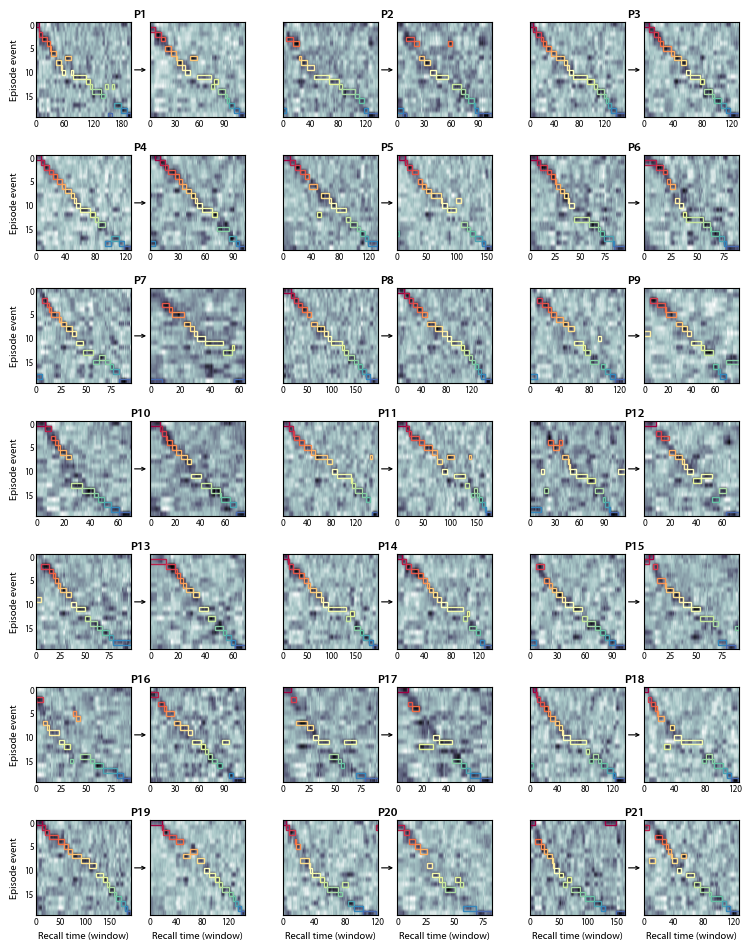

recall-eventseg-all-B.pdf


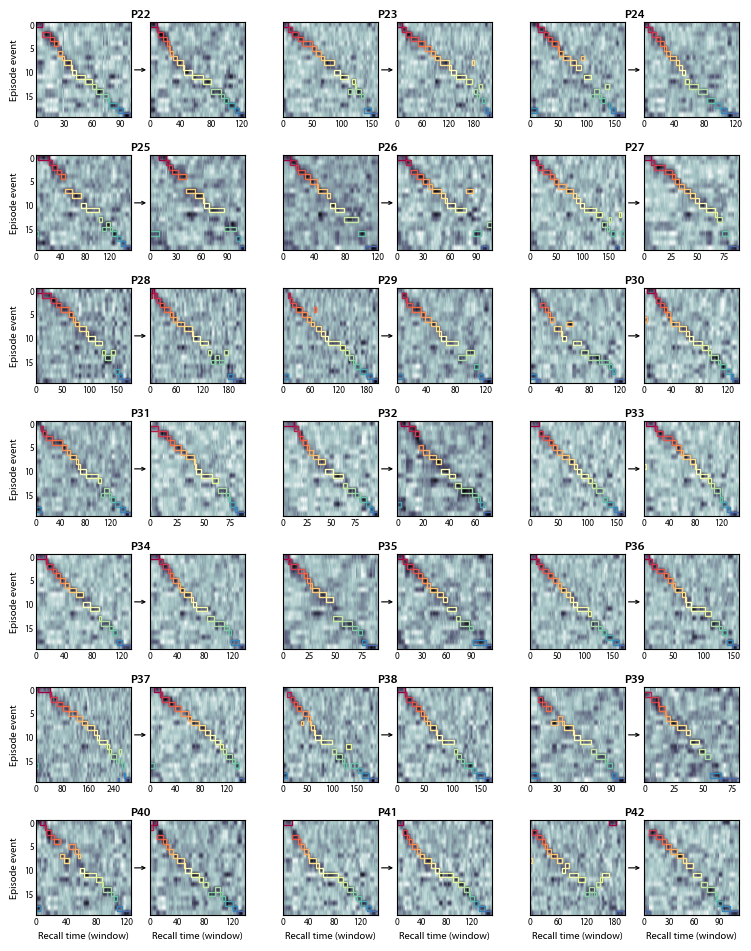

recall-eventseg-all-C.pdf


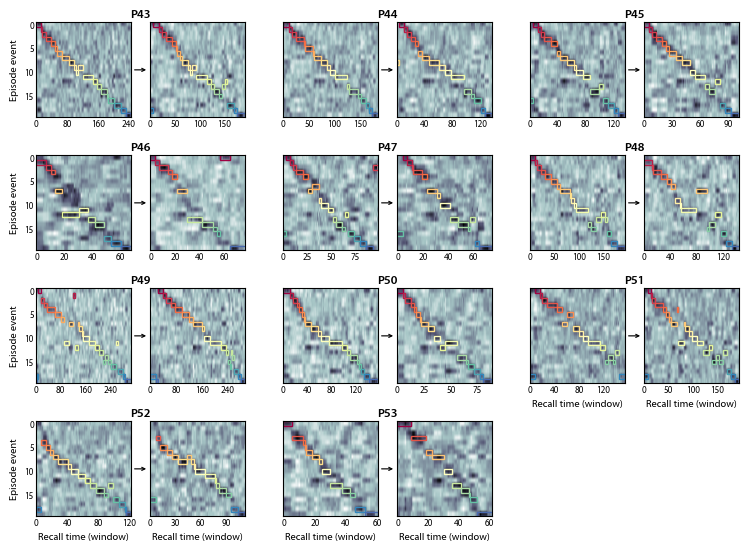

In [7]:
################################ CONFIG ################################

# plot styling
EVENTSEG_LINEWIDTH = 1
X_LABEL = 'Recall time (window)'
Y_LABEL = 'Episode event'
LABEL_FONTSIZE = 7.5
TICKLABEL_FONTSIZE = 6.5
TICKLABEL_PAD = -2
TITLE_FONTSIZE = 9
TITLE_FONTWEIGHT = 'semibold'
TITLE_PAD = 0.003

# multi-page layout
PAIRS_PER_ROW = 3
ROWS_PER_PAGE = 7
PANEL_SIZE_INCHES = 0.95
WITHIN_PAIR_GAP = 0.2
BETWEEN_PAIR_GAP = 0.4
ROW_GAP = 0.4

# immediate -> delayed arrows
GRID_SCALE = PANEL_SIZE_INCHES / 3.4
PAIR_ARROW_COLOR = 'k'
PAIR_ARROW_LINEWIDTH = 3 * GRID_SCALE
PAIR_ARROW_HEAD_SCALE = 20 * GRID_SCALE
PAIR_ARROW_LENGTH_FRAC = 0.9


########################################################################


# =========================== derived values ===========================

# location of each column's left edge, in panel units
col_xs = []
for pair_ix in range(PAIRS_PER_ROW):
    imm_plot_left = pair_ix * (2 + WITHIN_PAIR_GAP + BETWEEN_PAIR_GAP)
    col_xs.append(imm_plot_left)
    col_xs.append(imm_plot_left + 1 + WITHIN_PAIR_GAP)
    
# location of each row's top edge, in panel units
row_ys = []
for row_ix in range(ROWS_PER_PAGE):
    row_ys.append(row_ix + (row_ix + 1) * ROW_GAP)

    
# total width/height of each page's fig, in panel units
fig_width = (PAIRS_PER_ROW * (2 + WITHIN_PAIR_GAP) + 
             (PAIRS_PER_ROW - 1) * BETWEEN_PAIR_GAP)
fig_height = ROWS_PER_PAGE * (1 + ROW_GAP)

participants_per_page = PAIRS_PER_ROW * ROWS_PER_PAGE
n_pages = math.ceil(len(participants) / participants_per_page)

page_file_suffixes = string.ascii_uppercase[:n_pages]


# ========================== construct figure ==========================

for page_ix in range(n_pages):
    fig = plt.figure(figsize=(fig_width * PANEL_SIZE_INCHES, 
                              fig_height * PANEL_SIZE_INCHES))
#     fig.patch.set_alpha(0)

    # participants to show in the current page's fig
    page_participants = participants[
        page_ix * participants_per_page : (page_ix + 1) * participants_per_page
    ]
    
    axes_pairs = []
    for p_ix, p in enumerate(page_participants):
        row, pair_col = divmod(p_ix, PAIRS_PER_ROW)
        y_top = row_ys[row]
        is_leftmost = not pair_col
        is_bottom = p_ix >= len(page_participants) - PAIRS_PER_ROW
        
        
        # ====================== immediate recall ======================
        
        imm_axes_rect = panel_units_to_rect(x=col_xs[2 * pair_col], 
                                            y_top=y_top, 
                                            w=1, 
                                            h=1, 
                                            fig_width=fig_width, 
                                            fig_height=fig_height)
        imm_ax = fig.add_axes(imm_axes_rect)
        
        imm_eventseg_edgecolors = TRAJECTORY_CMAP(
            p.event_matches['atlep1'] / len(atlep1.events)
        )
        imm_traj_centered = mean_center(p.trajectories['atlep1'])
        cosmat_imm = 1 - cdist(imm_traj_centered, ep_events_centered, metric='cosine')
        aspect_ratio = cosmat_imm.shape[0] / cosmat_imm.shape[1]
        imm_ax.imshow(cosmat_imm.T, cmap=HEATMAP_CMAP, aspect=aspect_ratio)
        draw_eventseg_recall(imm_ax, 
                             p.event_bounds['atlep1'], 
                             p.event_matches['atlep1'], 
                             edgecolor=imm_eventseg_edgecolors, 
                             linewidth=EVENTSEG_LINEWIDTH)
        style_heatmap_axes(imm_ax, is_leftmost=is_leftmost, is_bottom=is_bottom)
        
        
        # ====================== delayed recall  =======================
        
        del_axes_rect = panel_units_to_rect(x=col_xs[2 * pair_col + 1], 
                                            y_top=y_top, 
                                            w=1, 
                                            h=1, 
                                            fig_width=fig_width, 
                                            fig_height=fig_height)
        del_ax = fig.add_axes(del_axes_rect)
        del_eventseg_edgecolors = TRAJECTORY_CMAP(
            p.event_matches['delayed'] / len(atlep1.events)
        )
        del_traj_centered = mean_center(p.trajectories['delayed'])
        cosmat_del = 1 - cdist(del_traj_centered, ep_events_centered, metric='cosine')
        aspect_ratio = cosmat_del.shape[0] / cosmat_del.shape[1]
        del_ax.imshow(cosmat_del.T, cmap=HEATMAP_CMAP, aspect=aspect_ratio)
        draw_eventseg_recall(del_ax, 
                             p.event_bounds['delayed'], 
                             p.event_matches['delayed'], 
                             edgecolor=del_eventseg_edgecolors, 
                             linewidth=EVENTSEG_LINEWIDTH)
        style_heatmap_axes(del_ax, is_leftmost=False, is_bottom=is_bottom)
        
        axes_pairs.append((p, imm_ax, del_ax))
        
        
    # =================== axes pair titles & arrows ====================
        
    fig.canvas.draw()
    
    for p, imm_ax, del_ax in axes_pairs:
        box_imm, box_del = imm_ax.get_position(), del_ax.get_position()
        x_center = (box_imm.x0 + box_del.x1) / 2
        assert box_imm.y1.round(5) == box_del.y1.round(5)
        y_top = max(box_imm.y1, box_del.y1)
        fig.text(x_center, 
                 y_top + TITLE_PAD, 
                 f'P{p.sub_n}', 
                 ha='center', 
                 va='bottom',
                 fontsize=TITLE_FONTSIZE, 
                 fontweight=TITLE_FONTWEIGHT)
        
        y_middle = (box_imm.y0 + box_imm.y1) / 2
        gap_center = (box_imm.x1 + box_del.x0) / 2
        half_len = (box_del.x0 - box_imm.x1) * PAIR_ARROW_LENGTH_FRAC / 2
        arrow = FancyArrowPatch((gap_center - half_len, y_middle), 
                                (gap_center + half_len, y_middle),
                                arrowstyle='->',
                                color=PAIR_ARROW_COLOR, 
                                mutation_scale=PAIR_ARROW_HEAD_SCALE, 
                                linewidth=PAIR_ARROW_LINEWIDTH,
                                transform=fig.transFigure, 
                                clip_on=False)
        fig.add_artist(arrow)
        
    filename = f'recall-eventseg-all-{page_file_suffixes[page_ix]}.pdf'
#     plt.savefig(FIG_DIR / filename, bbox_inches='tight')
    print(filename)
    plt.show()